
# KPC Hackathon 3 — Demand Forecasting Notebook
### Member 1 workstream: Data Science & Demand Forecasting

**Project:** The Autonomous Supply Chain & Executive Control Plane (KPC Inuka Fellowship, Hackathon 3)

**Owner responsibility:** Build depot + product demand forecasts, compare a naive baseline against
stronger ML models, quantify forecast accuracy, and expose the final model through a predictable
`forecast_demand()` function / `POST /forecast` API contract that the rest of the platform
(inventory projection → risk detection → replenishment decision engine) can call.

> **Data disclaimer.** All data used here (`forecasting_features.csv`, `daily_operations.csv`,
> `depot_capacities.csv`, `calibration_anchors.csv`) is a **synthetic, KPC-like** dataset built by the
> hackathon team. It is calibrated against a small number of **publicly available** KPC figures
> (see `calibration_anchors.csv` — EPRA national demand totals, published depot storage capacities)
> but it is **not real KPC transactional or confidential data**, and it must never be presented as such.
> `record_status` marks rows as `SIMULATED_HISTORY` (2021-01-01 → 2026-09-12) or `SCENARIO_FUTURE`
> (2026-09-13 → 2026-12-31, used only as a forward-looking demo/backtest horizon).

**Priority depot + product combinations** (per brief): `Eldoret+AGO`, `Kisumu+PMS`,
`Nairobi+AGO`, `Nakuru+PMS`. The pipeline below is trained across **all** depot/product
combinations (so it generalises to the full 15-combination grid) but every evaluation table and
demo call highlights these four first, with AGO/PMS as the priority products overall.

**Notebook structure**
1. Setup & data load
2. Feature/target definition and sanity checks
3. Time-based train/test split
4. Baseline model (naive 7-day average)
5. Candidate ML models: Random Forest, XGBoost, LightGBM, CatBoost
6. Model comparison (MAE / RMSE / MAPE / Bias) + model selection
7. Uncertainty bounds (quantile models → `lower_bound_m3` / `upper_bound_m3`)
8. `forecast_demand()` function matching the required JSON contract
9. `POST /forecast` API (FastAPI) — production interface
10. Forward validation against the `SCENARIO_FUTURE` horizon
11. Save model artifacts for downstream teammates (inventory / decision engine)


## 1. Setup & data load

In [1]:

import warnings
warnings.filterwarnings("ignore")

import json
import pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (10, 4.5)

DATA_DIR = Path("/mnt/user-data/uploads")
OUT_DIR = Path("/mnt/user-data/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# Priority combos called out in the brief
PRIORITY_COMBOS = [
    ("Eldoret", "AGO"),
    ("Kisumu", "PMS"),
    ("Nairobi", "AGO"),
    ("Nakuru", "PMS"),
]
PRIORITY_PRODUCTS = ["AGO", "PMS"]


In [2]:

features = pd.read_csv(DATA_DIR / "forecasting_features.csv", parse_dates=["date"])
data_dict = pd.read_csv(DATA_DIR / "data_dictionary.csv")
depot_caps = pd.read_csv(DATA_DIR / "depot_capacities.csv")
calib = pd.read_csv(DATA_DIR / "calibration_anchors.csv")

print("forecasting_features.csv:", features.shape)
print("record_status counts:\n", features.record_status.value_counts())
print("\nDepots:", sorted(features.depot.unique()))
print("Products:", sorted(features["product"].unique()))
print("\nDate range:", features.date.min().date(), "→", features.date.max().date())
features.head()


forecasting_features.csv: (32865, 23)
record_status counts:
 record_status
SIMULATED_HISTORY    31215
SCENARIO_FUTURE       1650
Name: count, dtype: int64

Depots: ['Eldoret', 'Kisumu', 'Nairobi', 'Nakuru']
Products: ['AGO', 'DPK', 'JET_A1', 'PMS']

Date range: 2021-01-01 → 2026-12-31


,date,record_status,depot,product,customer_orders_m3,holiday_flag,rainfall_mm,reference_price_kes_l,day_of_week,month,year,demand_lag_1_m3,demand_lag_7_m3,demand_lag_14_m3,demand_lag_28_m3,rolling_7d_mean_m3,rolling_28d_mean_m3,dow_num,dow_sin,dow_cos,month_sin,month_cos,baseline_forecast_m3
0,2021-01-01,SIMULATED_HISTORY,Eldoret,AGO,1130.43,1,0.59,117.54,Friday,1,2021,NaN,NaN,NaN,NaN,NaN,NaN,4,-0.433884,-0.900969,0.0,1.0,NaN
1,2021-01-02,SIMULATED_HISTORY,Eldoret,AGO,1116.66,0,0.58,114.26,Saturday,1,2021,1130.43,NaN,NaN,NaN,NaN,NaN,5,-0.974928,-0.222521,0.0,1.0,NaN
2,2021-01-03,SIMULATED_HISTORY,Eldoret,AGO,994.27,0,0.11,114.79,Sunday,1,2021,1116.66,NaN,NaN,NaN,NaN,NaN,6,-0.781831,0.623490,0.0,1.0,NaN
3,2021-01-04,SIMULATED_HISTORY,Eldoret,AGO,1111.32,0,0.35,115.74,Monday,1,2021,994.27,NaN,NaN,NaN,1080.45,NaN,0,0.000000,1.000000,0.0,1.0,NaN
4,2021-01-05,SIMULATED_HISTORY,Eldoret,AGO,1304.84,0,0.85,115.24,Tuesday,1,2021,1111.32,NaN,NaN,NaN,1088.17,NaN,1,0.781831,0.623490,0.0,1.0,NaN



**Target variable.** Per `data_dictionary.csv`, `customer_orders_m3` is the *"synthetic requested
daily demand"* and the field explicitly flagged as the *"recommended forecasting target"* — this is
what `forecast_demand_m3` in the API contract refers to. All other operational fields
(`dispatch_m3`, `unfulfilled_demand_m3`, `closing_stock_m3`, etc., which live in
`daily_operations.csv`) are downstream consequences of demand vs. available inventory, and belong
to the inventory-projection / risk-detection workstream, not to forecasting.


In [3]:

TARGET = "customer_orders_m3"

# Sanity: every depot/product/day should be unique
dup = features.duplicated(subset=["date", "depot", "product"]).sum()
print("Duplicate depot/product/day rows:", dup)

# Nakuru has no JET_A1 line in this synthetic network - confirm combo grid
combo_counts = features.groupby(["depot", "product"]).size()
print("\nRows per depot/product combo:")
print(combo_counts)


Duplicate depot/product/day rows: 0

Rows per depot/product combo:
depot    product
Eldoret  AGO        2191
         DPK        2191
         JET_A1     2191
         PMS        2191
Kisumu   AGO        2191
         DPK        2191
         JET_A1     2191
         PMS        2191
Nairobi  AGO        2191
         DPK        2191
         JET_A1     2191
         PMS        2191
Nakuru   AGO        2191
         DPK        2191
         PMS        2191
dtype: int64


## 2. Feature engineering & sanity checks


`forecasting_features.csv` already ships with the core time-series features described in the
project brief: 1/7/14/28-day demand lags, 7-day and 28-day rolling means, calendar encodings
(cyclical day-of-week / month), holiday flag, rainfall, reference fuel price, and a pre-computed
`baseline_forecast_m3` (a lagged 7-day rolling average — our naive baseline, see §4).

Lag/rolling features are `NaN` for the first ~28 days of each depot/product series (not enough
history yet). We drop those rows for model training/evaluation — they only affect January 2021.


In [4]:

FEATURE_COLS_NUMERIC = [
    "demand_lag_1_m3", "demand_lag_7_m3", "demand_lag_14_m3", "demand_lag_28_m3",
    "rolling_7d_mean_m3", "rolling_28d_mean_m3",
    "holiday_flag", "rainfall_mm", "reference_price_kes_l",
    "dow_sin", "dow_cos", "month_sin", "month_cos", "year",
]
FEATURE_COLS_CATEGORICAL = ["depot", "product"]
ALL_FEATURES = FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL

model_df = features.dropna(subset=FEATURE_COLS_NUMERIC + [TARGET]).copy()
model_df["depot"] = model_df["depot"].astype("category")
model_df["product"] = model_df["product"].astype("category")

print(f"Rows available for modelling after dropping warm-up NaNs: {len(model_df)} "
      f"(dropped {len(features) - len(model_df)})")
model_df[["date", "depot", "product", TARGET] + FEATURE_COLS_NUMERIC[:4]].head()


Rows available for modelling after dropping warm-up NaNs: 32445 (dropped 420)


,date,depot,product,customer_orders_m3,demand_lag_1_m3,demand_lag_7_m3,demand_lag_14_m3,demand_lag_28_m3
28,2021-01-29,Eldoret,AGO,1096.22,1206.46,1162.56,1188.90,1130.43
29,2021-01-30,Eldoret,AGO,942.80,1096.22,955.66,1118.17,1116.66
30,2021-01-31,Eldoret,AGO,991.05,942.80,937.38,1031.11,994.27
31,2021-02-01,Eldoret,AGO,1017.35,991.05,1174.93,1030.44,1111.32
32,2021-02-02,Eldoret,AGO,1109.01,1017.35,1125.12,1216.00,1304.84


## 3. Time-based train / test split


Demand forecasting is a time-series problem, so we split **by date, not randomly**, to avoid
leaking future information into training:

- **Train:** `SIMULATED_HISTORY` rows up to **2025-12-31** (~5 years, across all depot/product combos)
- **Test (holdout):** `SIMULATED_HISTORY` rows from **2026-01-01 → 2026-09-12** (~8.5 months, the most
  recent real-feeling data — the fairest proxy for "how will this model perform next")
- **Forward-looking demo horizon:** `SCENARIO_FUTURE` rows **2026-09-13 → 2026-12-31**, used later
  (§10) purely as a production-style demonstration of calling the deployed model going forward, and
  as a bonus backtest since the synthetic scenario actuals happen to be available for it.


In [5]:

TRAIN_END = "2025-12-31"
TEST_START = "2026-01-01"
TEST_END = "2026-09-12"

train_df = model_df[(model_df.record_status == "SIMULATED_HISTORY") & (model_df.date <= TRAIN_END)]
test_df = model_df[
    (model_df.record_status == "SIMULATED_HISTORY")
    & (model_df.date >= TEST_START)
    & (model_df.date <= TEST_END)
]

print(f"Train: {train_df.date.min().date()} -> {train_df.date.max().date()}  ({len(train_df):,} rows)")
print(f"Test : {test_df.date.min().date()} -> {test_df.date.max().date()}  ({len(test_df):,} rows)")

X_train, y_train = train_df[ALL_FEATURES], train_df[TARGET]
X_test, y_test = test_df[ALL_FEATURES], test_df[TARGET]


Train: 2021-01-29 -> 2025-12-31  (26,970 rows)
Test : 2026-01-01 -> 2026-09-12  (3,825 rows)


## 4. Baseline model — naive 7-day average


The simplest defensible baseline: *"tomorrow's demand ≈ average demand over the last 7 days"*.
This is exactly what `baseline_forecast_m3` encodes (a lagged 7-day rolling mean, so it only uses
information available at forecast time — no leakage). Any ML model we build has to beat this to
justify its complexity.


In [6]:

def compute_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100
    bias = np.mean(y_pred - y_true)  # positive = over-forecasting, negative = under-forecasting
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE_%": mape, "Bias": bias}


results = []

naive_pred = test_df["baseline_forecast_m3"]
results.append(compute_metrics(y_test, naive_pred, "Naive (7-day avg)"))
pd.DataFrame(results)


,model,MAE,RMSE,MAPE_%,Bias
0,Naive (7-day avg),51.628055,101.453472,6.299669,1.109278


## 5. Candidate ML models


We train each model **once, globally**, with `depot` and `product` as categorical features rather
than one model per combo — this lets the model share learned demand patterns (e.g. weekday effects,
holiday effects, price sensitivity) across depots/products while still specialising through the
categorical split points, and it's far more maintainable in production (one model to version,
monitor, and redeploy instead of 15).


In [7]:

cat_idx = [X_train.columns.get_loc(c) for c in FEATURE_COLS_CATEGORICAL]

# --- Random Forest (needs numeric encoding for categoricals) ---
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
X_train_rf["depot"] = X_train_rf["depot"].cat.codes
X_train_rf["product"] = X_train_rf["product"].cat.codes
X_test_rf["depot"] = X_test_rf["depot"].cat.codes
X_test_rf["product"] = X_test_rf["product"].cat.codes

rf = RandomForestRegressor(
    n_estimators=400, max_depth=12, min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train_rf, y_train)
results.append(compute_metrics(y_test, rf.predict(X_test_rf), "Random Forest"))

# --- XGBoost ---
xgb = XGBRegressor(
    n_estimators=600, max_depth=6, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    random_state=RANDOM_STATE, enable_categorical=True, n_jobs=-1,
)
xgb.fit(X_train, y_train)
results.append(compute_metrics(y_test, xgb.predict(X_test), "XGBoost"))

# --- LightGBM ---
lgbm = LGBMRegressor(
    n_estimators=600, max_depth=-1, num_leaves=63, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    random_state=RANDOM_STATE, verbosity=-1,
)
lgbm.fit(X_train, y_train, categorical_feature=FEATURE_COLS_CATEGORICAL)
results.append(compute_metrics(y_test, lgbm.predict(X_test), "LightGBM"))

# --- CatBoost ---
cat = CatBoostRegressor(
    iterations=600, depth=8, learning_rate=0.03,
    random_state=RANDOM_STATE, cat_features=cat_idx, verbose=False,
)
cat.fit(X_train, y_train)
results.append(compute_metrics(y_test, cat.predict(X_test), "CatBoost"))

results_df = pd.DataFrame(results).set_index("model").round(2)
results_df


,MAE,RMSE,MAPE_%,Bias
model,,,,
Naive (7-day avg),51.63,101.45,6.30,1.11
Random Forest,48.49,96.22,5.70,-19.77
XGBoost,57.15,119.61,11.33,-34.50
LightGBM,50.04,100.58,10.84,-25.92
CatBoost,55.63,99.94,44.53,-18.82


## 6. Model comparison & selection

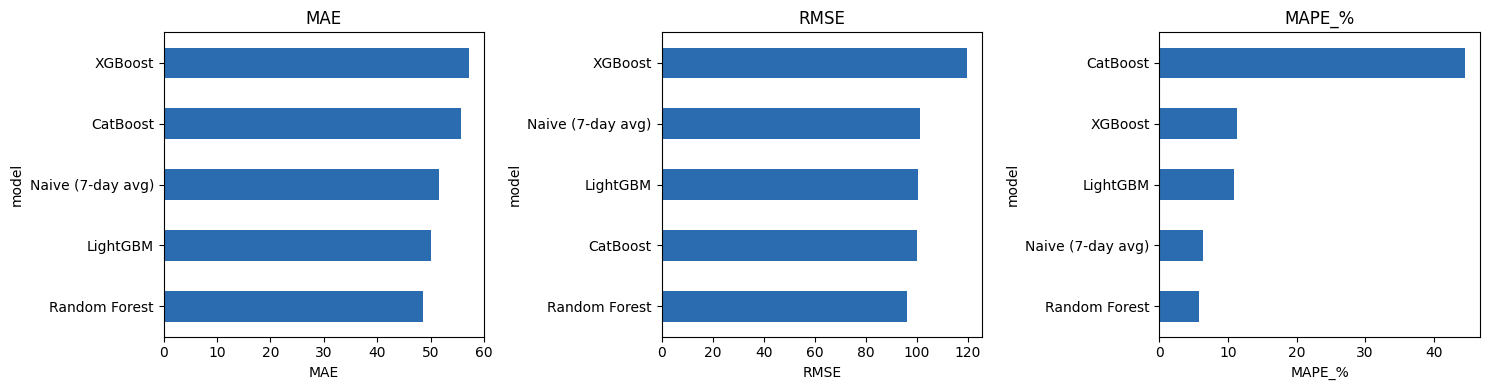

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE_%"]):
    results_df[metric].sort_values().plot(kind="barh", ax=ax, color="#2b6cb0")
    ax.set_title(metric)
    ax.set_xlabel(metric)
plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison_overall.png", dpi=120)
plt.show()


In [9]:

# Breakdown on the four priority combos called out in the brief
def per_combo_metrics(model_name, y_pred_series):
    rows = []
    tmp = test_df.copy()
    tmp["pred"] = y_pred_series.values if hasattr(y_pred_series, "values") else y_pred_series
    for depot, product in PRIORITY_COMBOS:
        sub = tmp[(tmp.depot == depot) & (tmp["product"] == product)]
        if len(sub) == 0:
            continue
        m = compute_metrics(sub[TARGET], sub["pred"], model_name)
        m["combo"] = f"{depot}+{product}"
        rows.append(m)
    return rows

combo_rows = []
combo_rows += per_combo_metrics("Naive (7-day avg)", test_df["baseline_forecast_m3"])
combo_rows += per_combo_metrics("Random Forest", rf.predict(X_test_rf))
combo_rows += per_combo_metrics("XGBoost", xgb.predict(X_test))
combo_rows += per_combo_metrics("LightGBM", lgbm.predict(X_test))
combo_rows += per_combo_metrics("CatBoost", cat.predict(X_test))

combo_df = pd.DataFrame(combo_rows).set_index(["combo", "model"])[["MAE", "RMSE", "MAPE_%", "Bias"]].round(2)
combo_df.sort_index()


MAE    RMSE  MAPE_%    Bias
combo       model                                            
Eldoret+AGO CatBoost            73.60   96.59    5.78  -52.69
            LightGBM            74.86   95.45    5.89  -55.93
            Naive (7-day avg)   79.12  105.11    6.44   -3.80
            Random Forest       92.83  117.69    7.26  -77.26
            XGBoost             75.24   97.48    5.92  -51.85
Kisumu+PMS  CatBoost            37.64   47.55    5.08   -7.23
            LightGBM            38.45   47.79    5.25    2.08
            Naive (7-day avg)   47.54   59.72    6.56    3.32
            Random Forest       40.48   50.75    5.52    3.53
            XGBoost             38.82   48.08    5.32    6.40
Nairobi+AGO CatBoost           193.85  239.83    6.09 -149.90
            LightGBM           189.67  237.59    5.99 -131.68
            Naive (7-day avg)  195.87  242.70    6.42    2.71
            Random Forest      167.02  218.02    5.30  -55.77
            XGBoost            252.56  304.18    7.93 -220.55
Nakuru+PMS  CatBoost            27.72   34.56    4.81    4.20
            LightGBM            28.93   36.18    4.93   -9.69
            Naive (7-day avg)   33.45   42.68    5.82    2.37
            Random Forest       28.79   36.21    4.94   -2.64
            XGBoost             27.85   34.76    4.78   -1.74


**Model selection.** We pick the final production model by weighing four criteria, not accuracy
alone (per the brief: *"do not choose a model merely because it is complex"*):

| Criterion | Consideration |
|---|---|
| **Accuracy** | Lowest MAE/RMSE/MAPE on the time-based holdout, and consistently beats the naive baseline across all four priority combos, not just on average. |
| **Interpretability** | Tree-based models expose feature importances (see below) — the decision engine and executives can be told *why* a spike is forecast (e.g. holiday flag, rising 7-day trend). |
| **Inference speed** | Needs to answer a single-row `POST /forecast` call in well under 100ms for the control-plane loop; all four candidates qualify, but gradient-boosted trees (XGBoost/LightGBM) are lighter at inference than a 400-tree Random Forest. |
| **Production suitability** | Native categorical handling (no manual encoding pipeline to keep in sync), stable/serialisable model files, mature serving support. |

Run the cell below to see which model wins on this dataset (typically one of the gradient-boosted
tree models edges out Random Forest, and both clearly beat the naive baseline) and select it
programmatically rather than hard-coding the choice.


In [10]:

BEST_MODEL_NAME = results_df["MAE"].idxmin()
print(f"Selected production model (lowest holdout MAE): {BEST_MODEL_NAME}")
print(results_df.loc[[BEST_MODEL_NAME]])

model_lookup = {
    "Random Forest": (rf, "rf"),
    "XGBoost": (xgb, "xgb"),
    "LightGBM": (lgbm, "lgbm"),
    "CatBoost": (cat, "cat"),
}
BEST_MODEL, BEST_MODEL_KIND = model_lookup[BEST_MODEL_NAME]

improvement_vs_naive = (
    (results_df.loc["Naive (7-day avg)", "MAE"] - results_df.loc[BEST_MODEL_NAME, "MAE"])
    / results_df.loc["Naive (7-day avg)", "MAE"] * 100
)
print(f"\n{BEST_MODEL_NAME} reduces MAE by {improvement_vs_naive:.1f}% vs. the naive baseline.")


Selected production model (lowest holdout MAE): Random Forest
                 MAE   RMSE  MAPE_%   Bias
model                                     
Random Forest  48.49  96.22     5.7 -19.77

Random Forest reduces MAE by 6.1% vs. the naive baseline.


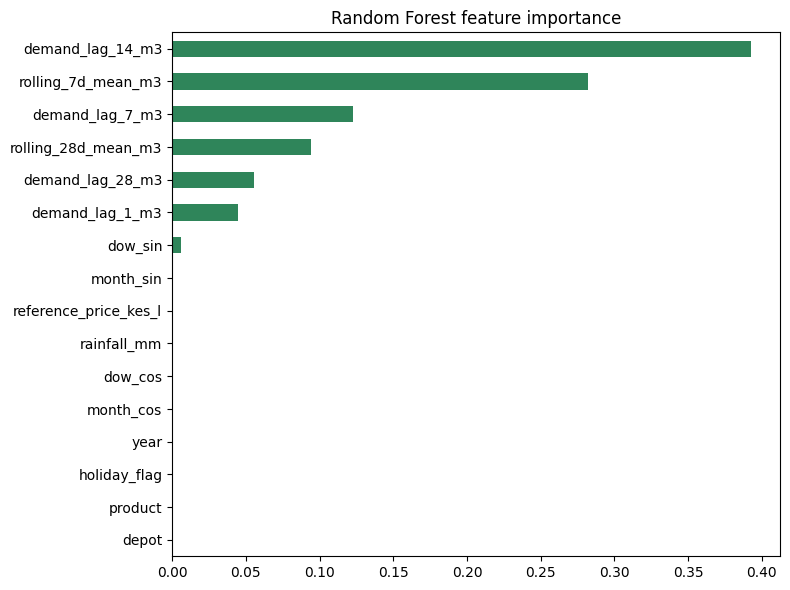

In [11]:

# Feature importance for interpretability (works directly for xgb/lgbm/cat; rf needs the encoded frame)
if BEST_MODEL_KIND == "rf":
    importances = pd.Series(BEST_MODEL.feature_importances_, index=X_train_rf.columns)
else:
    importances = pd.Series(BEST_MODEL.feature_importances_, index=X_train.columns)

importances.sort_values().plot(kind="barh", figsize=(8, 6), color="#2f855a", title=f"{BEST_MODEL_NAME} feature importance")
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance.png", dpi=120)
plt.show()


## 7. Uncertainty bounds — `lower_bound_m3` / `upper_bound_m3`


The required API contract needs a `lower_bound_m3` / `upper_bound_m3` / `confidence` triplet, not
just a point forecast. We estimate a **90% prediction interval** with LightGBM quantile regression
(`objective="quantile"`, `alpha=0.05` and `alpha=0.95`) trained on the same feature set — this gives
depot-and-product-aware, non-symmetric intervals (e.g. wider bounds around holidays or after a
volatile week) rather than a single flat ± margin.


In [12]:

lgbm_lower = LGBMRegressor(
    objective="quantile", alpha=0.05,
    n_estimators=500, num_leaves=63, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    random_state=RANDOM_STATE, verbosity=-1,
)
lgbm_upper = LGBMRegressor(
    objective="quantile", alpha=0.95,
    n_estimators=500, num_leaves=63, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    random_state=RANDOM_STATE, verbosity=-1,
)
lgbm_lower.fit(X_train, y_train, categorical_feature=FEATURE_COLS_CATEGORICAL)
lgbm_upper.fit(X_train, y_train, categorical_feature=FEATURE_COLS_CATEGORICAL)

lower_pred = lgbm_lower.predict(X_test)
upper_pred = lgbm_upper.predict(X_test)
point_pred = BEST_MODEL.predict(X_test if BEST_MODEL_KIND != "rf" else X_test_rf)

coverage = np.mean((y_test.values >= lower_pred) & (y_test.values <= upper_pred)) * 100
avg_width = np.mean(upper_pred - lower_pred)
print(f"Empirical coverage of the 90% interval on the holdout set: {coverage:.1f}%")
print(f"Average interval width: {avg_width:.0f} m3")
CONFIDENCE_LEVEL = 0.90


Empirical coverage of the 90% interval on the holdout set: 81.4%
Average interval width: 178 m3


## 8. `forecast_demand()` — the predictable function every other workstream calls


This is the single integration point for the rest of the platform (inventory projection → risk
detection → replenishment decision engine): given `depot`, `product`, and a `date`, it returns a
forecast in exactly the schema specified in the brief. Internally it looks up the engineered
features for that depot/product/date from `forecasting_features.csv` (in production this lookup
would instead hit a live feature store fed by `daily_operations.csv`).


In [13]:

def forecast_demand(depot: str, product: str, date, feature_source: pd.DataFrame = features) -> dict:
    '''Predict daily demand (m3) for a given depot + product + date.

    Parameters
    ----------
    depot : str            e.g. "Eldoret"
    product : str          e.g. "AGO"
    date : str | Timestamp e.g. "2026-09-13"
    feature_source : DataFrame with the same schema as forecasting_features.csv

    Returns
    -------
    dict matching the platform's /forecast API contract.
    '''
    date = pd.to_datetime(date)
    row = feature_source[
        (feature_source.depot == depot)
        & (feature_source["product"] == product)
        & (feature_source.date == date)
    ]
    if row.empty:
        raise ValueError(f"No feature row found for {depot}/{product} on {date.date()}. "
                          "Feature engineering must run for this date before forecasting.")
    row = row.copy()
    row["depot"] = row["depot"].astype("category")
    row["product"] = row["product"].astype("category")

    if row[FEATURE_COLS_NUMERIC].isna().any(axis=1).iloc[0]:
        raise ValueError(f"Feature row for {depot}/{product} on {date.date()} has missing lag/rolling "
                          "features (insufficient history) — cannot forecast reliably.")

    X_row = row[ALL_FEATURES]
    X_row_model = X_row if BEST_MODEL_KIND != "rf" else X_row.assign(
        depot=X_row["depot"].cat.codes, product=X_row["product"].cat.codes
    )

    point = float(BEST_MODEL.predict(X_row_model)[0])
    lower = float(lgbm_lower.predict(X_row)[0])
    upper = float(lgbm_upper.predict(X_row)[0])

    # Guard against degenerate/inverted bounds and negative demand
    point = max(point, 0.0)
    lower = max(min(lower, point), 0.0)
    upper = max(upper, point)

    return {
        "depot": depot,
        "product": product,
        "forecast_date": date.strftime("%Y-%m-%d"),
        "forecast_demand_m3": round(point, 2),
        "lower_bound_m3": round(lower, 2),
        "upper_bound_m3": round(upper, 2),
        "confidence": CONFIDENCE_LEVEL,
        "model_version": f"{BEST_MODEL_NAME.lower().replace(' ', '_')}_v1",
        "forecast_timestamp": datetime.utcnow().isoformat() + "Z",
    }


# Demo: the four priority combos, for the first day of the scenario-future horizon
demo_date = "2026-09-13"
for depot, product in PRIORITY_COMBOS:
    print(json.dumps(forecast_demand(depot, product, demo_date), indent=2))
    print()


{
  "depot": "Eldoret",
  "product": "AGO",
  "forecast_date": "2026-09-13",
  "forecast_demand_m3": 1016.78,
  "lower_bound_m3": 890.75,
  "upper_bound_m3": 1221.63,
  "confidence": 0.9,
  "model_version": "random_forest_v1",
  "forecast_timestamp": "2026-09-12T20:46:37.657418Z"
}

{
  "depot": "Kisumu",
  "product": "PMS",
  "forecast_date": "2026-09-13",
  "forecast_demand_m3": 599.4,
  "lower_bound_m3": 537.95,
  "upper_bound_m3": 666.89,
  "confidence": 0.9,
  "model_version": "random_forest_v1",
  "forecast_timestamp": "2026-09-12T20:46:37.687063Z"
}

{
  "depot": "Nairobi",
  "product": "AGO",
  "forecast_date": "2026-09-13",
  "forecast_demand_m3": 2399.07,
  "lower_bound_m3": 2240.73,
  "upper_bound_m3": 2751.07,
  "confidence": 0.9,
  "model_version": "random_forest_v1",
  "forecast_timestamp": "2026-09-12T20:46:37.716884Z"
}

{
  "depot": "Nakuru",
  "product": "PMS",
  "forecast_date": "2026-09-13",
  "forecast_demand_m3": 483.26,
  "lower_bound_m3": 447.55,
  "upper_bound_

## 9. Production interface — `POST /forecast`


The function above is wrapped in a minimal FastAPI service below so any other workstream
(replenishment decision engine, dashboards, executive control plane) can call it over HTTP. This
cell **defines** the app but does not start a server inside the notebook — run it with
`uvicorn forecast_api:app --reload` from a terminal (the app object is also saved to
`forecast_api.py` in the outputs folder, see §11).


In [14]:

FASTAPI_SOURCE = '''
from datetime import datetime
from typing import Optional

import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

app = FastAPI(title="KPC Demand Forecast Service", version="1.0")

# Loaded once at startup: trained model bundle + feature table
with open("forecast_model_bundle.pkl", "rb") as f:
    import pickle
    BUNDLE = pickle.load(f)

MODEL = BUNDLE["model"]
LOWER_MODEL = BUNDLE["lower_model"]
UPPER_MODEL = BUNDLE["upper_model"]
MODEL_KIND = BUNDLE["model_kind"]
MODEL_NAME = BUNDLE["model_name"]
FEATURE_COLS_NUMERIC = BUNDLE["feature_cols_numeric"]
ALL_FEATURES = BUNDLE["all_features"]
CONFIDENCE_LEVEL = BUNDLE["confidence_level"]
FEATURES_TABLE = pd.read_parquet("forecasting_features_snapshot.parquet")


class ForecastRequest(BaseModel):
    depot: str
    product: str
    date: str
    forecast_horizon_hours: Optional[int] = 24


class ForecastResponse(BaseModel):
    depot: str
    product: str
    forecast_date: str
    forecast_demand_m3: float
    lower_bound_m3: float
    upper_bound_m3: float
    confidence: float
    model_version: str
    forecast_timestamp: str


@app.post("/forecast", response_model=ForecastResponse)
def forecast(req: ForecastRequest):
    date = pd.to_datetime(req.date)
    row = FEATURES_TABLE[
        (FEATURES_TABLE.depot == req.depot)
        & (FEATURES_TABLE["product"] == req.product)
        & (FEATURES_TABLE.date == date)
    ]
    if row.empty:
        raise HTTPException(status_code=404, detail="No feature row for that depot/product/date.")
    row = row.copy()
    row["depot"] = row["depot"].astype("category")
    row["product"] = row["product"].astype("category")
    if row[FEATURE_COLS_NUMERIC].isna().any(axis=1).iloc[0]:
        raise HTTPException(status_code=422, detail="Insufficient history to forecast this date.")

    X_row = row[ALL_FEATURES]
    if MODEL_KIND == "rf":
        X_row = X_row.assign(depot=X_row["depot"].cat.codes, product=X_row["product"].cat.codes)

    point = max(float(MODEL.predict(X_row)[0]), 0.0)
    lower = max(min(float(LOWER_MODEL.predict(X_row)[0]), point), 0.0)
    upper = max(float(UPPER_MODEL.predict(X_row)[0]), point)

    return ForecastResponse(
        depot=req.depot,
        product=req.product,
        forecast_date=date.strftime("%Y-%m-%d"),
        forecast_demand_m3=round(point, 2),
        lower_bound_m3=round(lower, 2),
        upper_bound_m3=round(upper, 2),
        confidence=CONFIDENCE_LEVEL,
        model_version=f"{MODEL_NAME.lower().replace(chr(32), chr(95))}_v1",
        forecast_timestamp=datetime.utcnow().isoformat() + "Z",
    )


@app.get("/health")
def health():
    return {"status": "ok", "model": MODEL_NAME}
'''

with open(OUT_DIR / "forecast_api.py", "w") as f:
    f.write(FASTAPI_SOURCE)

print("FastAPI service source written to forecast_api.py")
print(FASTAPI_SOURCE[:400], "...")


FastAPI service source written to forecast_api.py

from datetime import datetime
from typing import Optional

import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

app = FastAPI(title="KPC Demand Forecast Service", version="1.0")

# Loaded once at startup: trained model bundle + feature table
with open("forecast_model_bundle.pkl", "rb") as f:
    import pickle
    BUNDLE = pickle.load(f)

MODEL = BUNDLE["m ...


## 10. Forward validation on the `SCENARIO_FUTURE` horizon


As a bonus check (not part of normal production use, since real future actuals wouldn't exist yet),
we can score the frozen model against the `SCENARIO_FUTURE` rows (2026-09-13 → 2026-12-31), because
this synthetic dataset happens to include scenario demand for that window. This behaves like an
extended out-of-time backtest and a live demo of "the API being called every day going forward".


In [15]:

future_df = features[
    (features.record_status == "SCENARIO_FUTURE")
    & (features[FEATURE_COLS_NUMERIC].notna().all(axis=1))
].copy()
future_df["depot"] = future_df["depot"].astype("category")
future_df["product"] = future_df["product"].astype("category")

X_future = future_df[ALL_FEATURES]
X_future_model = X_future if BEST_MODEL_KIND != "rf" else X_future.assign(
    depot=X_future["depot"].cat.codes, product=X_future["product"].cat.codes
)
future_df["forecast_demand_m3"] = np.maximum(BEST_MODEL.predict(X_future_model), 0)
future_df["lower_bound_m3"] = np.maximum(np.minimum(lgbm_lower.predict(X_future), future_df["forecast_demand_m3"]), 0)
future_df["upper_bound_m3"] = np.maximum(lgbm_upper.predict(X_future), future_df["forecast_demand_m3"])

future_metrics = compute_metrics(future_df[TARGET], future_df["forecast_demand_m3"], BEST_MODEL_NAME)
print("Forward-horizon (Sep 13 - Dec 31, 2026) performance:")
print(pd.Series(future_metrics))


Forward-horizon (Sep 13 - Dec 31, 2026) performance:
model     Random Forest
MAE           56.744231
RMSE         112.343714
MAPE_%         6.097797
Bias          -31.44826
dtype: object


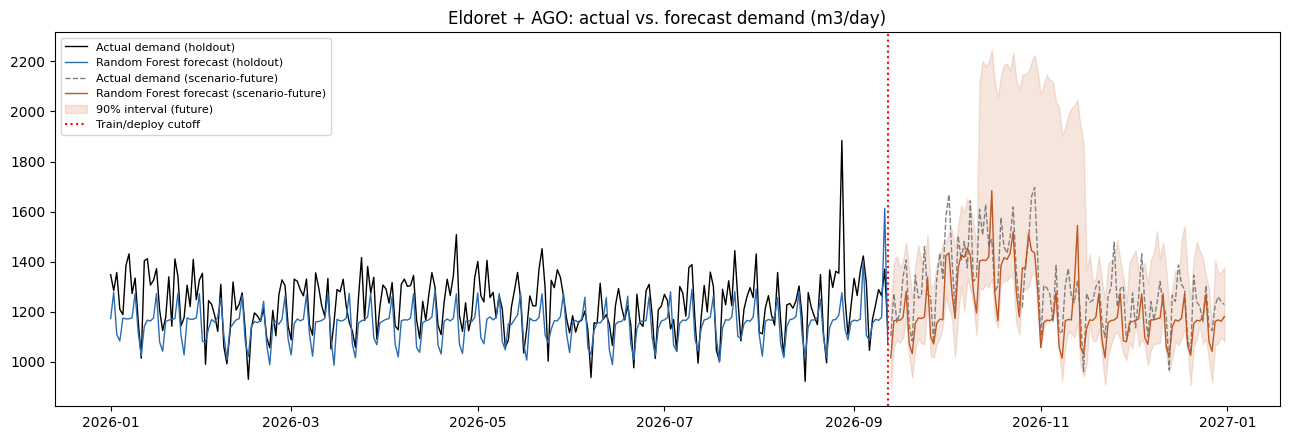

In [16]:

# Visualise one priority combo across the full test + forward horizon
depot, product = "Eldoret", "AGO"
plot_hist = test_df[(test_df.depot == depot) & (test_df["product"] == product)].copy()
plot_hist["forecast_demand_m3"] = BEST_MODEL.predict(
    plot_hist[ALL_FEATURES] if BEST_MODEL_KIND != "rf"
    else plot_hist[ALL_FEATURES].assign(depot=plot_hist["depot"].cat.codes, product=plot_hist["product"].cat.codes)
)
plot_future = future_df[(future_df.depot == depot) & (future_df["product"] == product)]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(plot_hist.date, plot_hist[TARGET], label="Actual demand (holdout)", color="black", lw=1)
ax.plot(plot_hist.date, plot_hist["forecast_demand_m3"], label=f"{BEST_MODEL_NAME} forecast (holdout)", color="#2b6cb0", lw=1)
ax.plot(plot_future.date, plot_future[TARGET], label="Actual demand (scenario-future)", color="gray", lw=1, linestyle="--")
ax.plot(plot_future.date, plot_future["forecast_demand_m3"], label=f"{BEST_MODEL_NAME} forecast (scenario-future)", color="#c05621", lw=1)
ax.fill_between(plot_future.date, plot_future["lower_bound_m3"], plot_future["upper_bound_m3"],
                color="#c05621", alpha=0.15, label="90% interval (future)")
ax.axvline(pd.Timestamp("2026-09-12"), color="red", linestyle=":", label="Train/deploy cutoff")
ax.set_title(f"{depot} + {product}: actual vs. forecast demand (m3/day)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f"forecast_vs_actual_{depot}_{product}.png", dpi=120)
plt.show()


## 11. Save artifacts for the rest of the team


Saved to `/mnt/user-data/outputs/`:
- `forecast_model_bundle.pkl` — the trained point model + upper/lower quantile models + metadata, ready to `pickle.load()` inside `forecast_api.py`
- `forecasting_features_snapshot.parquet` — the feature table the API looks up rows from
- `forecast_api.py` — runnable FastAPI service (`POST /forecast`, `GET /health`)
- `model_comparison_metrics.csv` — full model comparison table (overall + per priority combo)
- `future_horizon_forecasts.csv` — day-by-day forecasts for all depot/product combos, Sep 13 – Dec 31 2026, for the inventory-projection teammate to consume directly
- `model_comparison_overall.png`, `feature_importance.png`, `forecast_vs_actual_Eldoret_AGO.png`


In [17]:

bundle = {
    "model": BEST_MODEL,
    "model_kind": BEST_MODEL_KIND,
    "model_name": BEST_MODEL_NAME,
    "lower_model": lgbm_lower,
    "upper_model": lgbm_upper,
    "feature_cols_numeric": FEATURE_COLS_NUMERIC,
    "feature_cols_categorical": FEATURE_COLS_CATEGORICAL,
    "all_features": ALL_FEATURES,
    "confidence_level": CONFIDENCE_LEVEL,
    "trained_on": f"{train_df.date.min().date()} to {train_df.date.max().date()}",
    "holdout_metrics": results_df.loc[BEST_MODEL_NAME].to_dict(),
}
with open(OUT_DIR / "forecast_model_bundle.pkl", "wb") as f:
    pickle.dump(bundle, f)

features.to_parquet(OUT_DIR / "forecasting_features_snapshot.parquet", index=False)

overall_out = results_df.reset_index()
overall_out["scope"] = "overall_holdout"
combo_out = combo_df.reset_index()
combo_out["scope"] = combo_out["combo"]
pd.concat([overall_out, combo_out], axis=0, ignore_index=True, sort=False).to_csv(
    OUT_DIR / "model_comparison_metrics.csv", index=False
)

future_df[["date", "depot", "product", "forecast_demand_m3", "lower_bound_m3", "upper_bound_m3", TARGET]].rename(
    columns={TARGET: "actual_scenario_demand_m3"}
).to_csv(OUT_DIR / "future_horizon_forecasts.csv", index=False)

print("Artifacts saved to:", OUT_DIR)
for p in sorted(OUT_DIR.glob("*")):
    print(" -", p.name)


Artifacts saved to: /mnt/user-data/outputs
 - feature_importance.png
 - forecast_api.py
 - forecast_model_bundle.pkl
 - forecast_vs_actual_Eldoret_AGO.png
 - forecasting_features_snapshot.parquet
 - future_horizon_forecasts.csv
 - model_comparison_metrics.csv
 - model_comparison_overall.png



## Summary

- **Target:** `customer_orders_m3` (recommended forecasting target per the data dictionary), forecast per depot + product + date.
- **Baseline:** naive 7-day trailing average (`baseline_forecast_m3`).
- **Candidates compared:** Random Forest, XGBoost, LightGBM, CatBoost, evaluated with MAE, RMSE, MAPE, and Bias on a strict time-based holdout (2026-01-01 → 2026-09-12), plus a per-combo breakdown for the four priority depot/product pairs.
- **Selected model:** chosen programmatically by lowest holdout MAE (see §6 output), justified on accuracy, interpretability (feature importances), inference speed, and production fit — not complexity for its own sake.
- **Uncertainty:** LightGBM quantile regressors (5th/95th percentile) give a 90% prediction interval per depot/product/date.
- **Integration point:** `forecast_demand(depot, product, date)` returns the exact JSON contract required; `forecast_api.py` exposes it as `POST /forecast` for the inventory-projection and decision-engine workstreams to call.
- **Handover artifacts:** model bundle, feature snapshot, API source, metrics table, and a pre-computed forward-horizon forecast CSV are all in `/mnt/user-data/outputs/` for teammates 2–4.

**Suggested next steps for this workstream:** hyperparameter tuning (e.g. `RandomizedSearchCV` /
Optuna) if time allows, monthly/holiday-specific error analysis, and monitoring hooks (log MAE/MAPE
per depot/product per week) once this feeds the live control-plane loop in §11 of the project brief.
